# Importing libraries

In [ ]:
import pandas as pd 
import numpy as np 
import re
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
Path = "../data/dataset-tickets.csv"

# View data

In [21]:
df = pd.read_csv(Path)

In [10]:
df.isnull().sum()

subject      3838
body            0
answer          7
type            0
queue           0
priority        0
language        0
version         0
tag_1           0
tag_2          13
tag_3         136
tag_4        3058
tag_5       14042
tag_6       22713
tag_7       26547
tag_8       28022
dtype: int64

In [22]:
df.head(3)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


In [23]:
df['language'].value_counts()

language
en    16338
de    12249
Name: count, dtype: int64

In [24]:
df['type'].value_counts()

type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

In [25]:
df['queue'].value_counts()

queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

In [26]:
df['priority'].value_counts()

priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

# Cleaning

## Text (Subject, Body, Answer)

In [27]:
def text_normalize(text, language): 
    if not isinstance(text, str) or not text.strip():
        return ''
    
    text = text.lower()
    
    if language == 'de':
         text = re.sub(r'[^a-zäöüß0-9\s\-]', ' ', text)
         text = re.sub(r'[!\"#$%&\'()*+,./:;<=>?@\[\\\]^_`{|}~]', ' ', text)
         
    elif language == 'en':
        text = re.sub(r'[^a-z0-9\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [28]:
text_columns = ['subject','body','answer']

for col in text_columns:
    df[col] = df[col].fillna('').astype(str)
    de_mask = df['language'] == 'de'
    df.loc[de_mask, col] = df.loc[de_mask, col].apply(lambda x: text_normalize(x, 'de'))
    en_mask = df['language'] == 'en'
    df.loc[en_mask, col] = df.loc[en_mask, col].apply(lambda x: text_normalize(x, 'en'))

In [29]:
df.head(2)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,wesentlicher sicherheitsvorfall,sehr geehrtes support-team n nich möchte einen...,vielen dank für die meldung des kritischen sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,account disruption,dear customer support team n ni am writing to ...,thank you for reaching out name we are aware o...,Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN


In [30]:
df['body_length'] = df['body'].str.len()
df['answer_length'] = df['answer'].str.len()

## Tags

In [31]:
def clean_tag(tag: str):
    if not isinstance(tag, str):
        return ''
    
    tag = tag.lower().strip()
    tag = re.sub(r'[;|/]+', ',', tag)
    tag = re.sub(r'[-_]', ' ', tag)
    tag = re.sub(r'\s+', ' ', tag)
    if tag in ('nan', 'none', 'null', 'empty'):
        return ''
    return tag.strip()

In [32]:
tag_columns = [f'tag_{i}' for i in range(1, 9)]

for col in tag_columns:
    if col in df.columns:
        df[col] = df[col].fillna('').apply(clean_tag)
    else:
        df[col] = ''

In [33]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,body_length,answer_length
0,wesentlicher sicherheitsvorfall,sehr geehrtes support-team n nich möchte einen...,vielen dank für die meldung des kritischen sic...,Incident,Technical Support,high,de,51,security,outage,disruption,data breach,,,,,741,634
1,account disruption,dear customer support team n ni am writing to ...,thank you for reaching out name we are aware o...,Incident,Technical Support,high,en,51,account,disruption,outage,it,tech support,,,,534,488
2,query about smart home system integration feat...,dear customer support team n ni hope this mess...,thank you for your inquiry our products suppor...,Request,Returns and Exchanges,medium,en,51,product,feature,tech support,,,,,,526,494
3,inquiry regarding invoice details,dear customer support team n ni hope this mess...,we appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,billing,payment,account,documentation,feedback,,,,593,532
4,question about marketing agency software compa...,dear support team n ni hope this message reach...,thank you for your inquiry our product support...,Problem,Sales and Pre-Sales,medium,en,51,product,feature,feedback,tech support,,,,,667,268


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   subject        28587 non-null  object
 1   body           28587 non-null  object
 2   answer         28587 non-null  object
 3   type           28587 non-null  object
 4   queue          28587 non-null  object
 5   priority       28587 non-null  object
 6   language       28587 non-null  object
 7   version        28587 non-null  int64 
 8   tag_1          28587 non-null  object
 9   tag_2          28587 non-null  object
 10  tag_3          28587 non-null  object
 11  tag_4          28587 non-null  object
 12  tag_5          28587 non-null  object
 13  tag_6          28587 non-null  object
 14  tag_7          28587 non-null  object
 15  tag_8          28587 non-null  object
 16  body_length    28587 non-null  int64 
 17  answer_length  28587 non-null  int64 
dtypes: int64(3), object(15)
me

In [35]:
def combine_tags_for_ticket(row, tag_cols):
    tags = [t for t in (row[c] for c in tag_cols) if isinstance(t, str) and t.strip()]
    seen = set()
    uniq = []
    for t in tags:
        if t not in seen:
            seen.add(t)
            uniq.append(t)
    return " ".join(uniq)

In [36]:
df['tags_combined'] = df.apply(lambda r: combine_tags_for_ticket(r, tag_columns), axis=1)

In [37]:
print("Примеры tags_combined (первые 10):")
display(df['tags_combined'].head(10).tolist())

Примеры tags_combined (первые 10):


['security outage disruption data breach',
 'account disruption outage it tech support',
 'product feature tech support',
 'billing payment account documentation feedback',
 'product feature feedback tech support',
 'feature product documentation feedback',
 'outage disruption performance it tech support',
 'network hardware performance bug compatibility',
 'documentation feedback it tech support',
 'disruption outage recovery support']

# Embedding

In [38]:
model = SentenceTransformer("distiluse-base-multilingual-cased-v2")

texts = df['tags_combined'].fillna('').astype(str)
indexes = texts.index.to_list()

embeddings = model.encode(texts.tolist(), show_progress_bar=True)

Batches:   5%|▌         | 45/894 [00:53<16:48,  1.19s/it]


KeyboardInterrupt: 

In [ ]:
emb_df = pd.DataFrame({
    'idx_for_merge': indexes,
    'embedding': list(embeddings)
})

In [ ]:
df = df.reset_index(drop=False).rename(columns={'index': 'orig_index'})

In [ ]:
df = df.merge(emb_df, left_on='orig_index', right_on='idx_for_merge', how='left')

In [ ]:
df = df.drop(columns=['orig_index', 'idx_for_merge'])

In [ ]:
df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,body_length,answer_length,tags_combined,embedding
0,wesentlicher sicherheitsvorfall,sehr geehrtes support-team n nich möchte einen...,vielen dank für die meldung des kritischen sic...,Incident,Technical Support,high,de,51,security,outage,disruption,data breach,,,,,741,634,security outage disruption data breach,"[-0.010339236, 0.026312996, -0.02845551, 0.048..."
1,account disruption,dear customer support team n ni am writing to ...,thank you for reaching out name we are aware o...,Incident,Technical Support,high,en,51,account,disruption,outage,it,tech support,,,,534,488,account disruption outage it tech support,"[-0.07264027, -0.0054970314, 0.03760734, 0.016..."
2,query about smart home system integration feat...,dear customer support team n ni hope this mess...,thank you for your inquiry our products suppor...,Request,Returns and Exchanges,medium,en,51,product,feature,tech support,,,,,,526,494,product feature tech support,"[-0.029368442, 0.0626825, 0.008229229, 0.01602..."
3,inquiry regarding invoice details,dear customer support team n ni hope this mess...,we appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,billing,payment,account,documentation,feedback,,,,593,532,billing payment account documentation feedback,"[-0.07255821, -0.025548236, 0.010980651, 0.022..."
4,question about marketing agency software compa...,dear support team n ni hope this message reach...,thank you for your inquiry our product support...,Problem,Sales and Pre-Sales,medium,en,51,product,feature,feedback,tech support,,,,,667,268,product feature feedback tech support,"[-0.0356531, 0.03832313, -0.021160718, 0.01627..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28582,performance problem with data analytics tool,the data analytics tool experiences sluggish p...,we are addressing the performance issue with t...,Incident,Technical Support,high,en,400,performance,it,tech support,,,,,,74,266,performance it tech support,"[-0.08990499, 0.047382362, -0.023877406, 0.025..."
28583,datensperrung in der kundschaftsbetreuung,es gab einen datensperrungsunfall bei dem unge...,ich kann ihnen bei dem datensperrungsunfall he...,Incident,Product Support,high,de,400,security,it,tech support,bug,,,,,406,397,security it tech support bug,"[-0.018605042, 0.021855267, -0.0055052456, 0.0..."
28584,problem mit der videokonferenz-software heute,wichtigere sitzungen wurden unterbrochen durch...,sehr geehrte r name leider wurde das problem m...,Incident,Human Resources,low,de,400,bug,performance,network,it,tech support,,,,235,579,bug performance network it tech support,"[-0.07437406, 0.008218175, -0.05964678, 0.0147..."
28585,update request for saas platform integration f...,requesting an update on the integration featur...,received your request for updates on the integ...,Change,IT Support,high,en,400,feature,it,tech support,,,,,,281,264,feature it tech support,"[-0.04219642, 0.011036422, -0.011164758, 0.019..."


In [ ]:
missing_emb = df['embedding'].isna().sum()
print("Пропущенных embedding:", missing_emb)

Пропущенных embedding: 0


In [ ]:
out_path = r"../data/df_with_embedding.csv"
df.to_csv(out_path, index=False)
print("Saved to", out_path)

Saved to C:\Workspace\Python Playground\df_with_embedding.csv


# Looking for a numer of clusters

In [19]:
out_path = r"../data/df_with_embedding.csv"

In [40]:
df = pd.read_csv(out_path)

In [41]:
df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,body_length,answer_length,tags_combined,embedding
0,wesentlicher sicherheitsvorfall,sehr geehrtes support-team n nich möchte einen...,vielen dank für die meldung des kritischen sic...,Incident,Technical Support,high,de,51,security,outage,disruption,data breach,NaN,NaN,NaN,NaN,741,634,security outage disruption data breach,[-1.03392359e-02 2.63129957e-02 -2.84555107e-...
1,account disruption,dear customer support team n ni am writing to ...,thank you for reaching out name we are aware o...,Incident,Technical Support,high,en,51,account,disruption,outage,it,tech support,NaN,NaN,NaN,534,488,account disruption outage it tech support,[-7.26402700e-02 -5.49703138e-03 3.76073383e-...
2,query about smart home system integration feat...,dear customer support team n ni hope this mess...,thank you for your inquiry our products suppor...,Request,Returns and Exchanges,medium,en,51,product,feature,tech support,NaN,NaN,NaN,NaN,NaN,526,494,product feature tech support,[-2.93684416e-02 6.26825020e-02 8.22922867e-...
3,inquiry regarding invoice details,dear customer support team n ni hope this mess...,we appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,billing,payment,account,documentation,feedback,NaN,NaN,NaN,593,532,billing payment account documentation feedback,[-0.07255821 -0.02554824 0.01098065 0.022927...
4,question about marketing agency software compa...,dear support team n ni hope this message reach...,thank you for your inquiry our product support...,Problem,Sales and Pre-Sales,medium,en,51,product,feature,feedback,tech support,NaN,NaN,NaN,NaN,667,268,product feature feedback tech support,[-0.0356531 0.03832313 -0.02116072 0.016278...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28582,performance problem with data analytics tool,the data analytics tool experiences sluggish p...,we are addressing the performance issue with t...,Incident,Technical Support,high,en,400,performance,it,tech support,NaN,NaN,NaN,NaN,NaN,74,266,performance it tech support,[-8.99049863e-02 4.73823622e-02 -2.38774065e-...
28583,datensperrung in der kundschaftsbetreuung,es gab einen datensperrungsunfall bei dem unge...,ich kann ihnen bei dem datensperrungsunfall he...,Incident,Product Support,high,de,400,security,it,tech support,bug,NaN,NaN,NaN,NaN,406,397,security it tech support bug,[-1.86050422e-02 2.18552668e-02 -5.50524564e-...
28584,problem mit der videokonferenz-software heute,wichtigere sitzungen wurden unterbrochen durch...,sehr geehrte r name leider wurde das problem m...,Incident,Human Resources,low,de,400,bug,performance,network,it,tech support,NaN,NaN,NaN,235,579,bug performance network it tech support,[-7.43740574e-02 8.21817480e-03 -5.96467815e-...
28585,update request for saas platform integration f...,requesting an update on the integration featur...,received your request for updates on the integ...,Change,IT Support,high,en,400,feature,it,tech support,NaN,NaN,NaN,NaN,NaN,281,264,feature it tech support,[-0.04219642 0.01103642 -0.01116476 0.019883...


In [42]:
def fix_emb_spaces(x):
    if isinstance(x, str):
        x = x.replace('\n', ' ').strip()      # убрать переносы строк
        x = x.strip('[]')                     # убрать []
        x = x.split()                         # разбить по пробелам
        return np.array([float(n) for n in x], dtype=np.float32)
    return np.array(x, dtype=np.float32)

df['embedding'] = df['embedding'].apply(fix_emb_spaces)
X = np.vstack(df['embedding'].values)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразуем embeddings в numpy матрицу if нужно
X = np.vstack(df['embedding'].values)

k_values = list(range(10, 26))

inertias = []
sil_scores = []
ch_scores = []

for k in k_values:
    print(f"Training KMeans for k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

print("Done!")


Training KMeans for k=10...
Training KMeans for k=11...
Training KMeans for k=12...
Training KMeans for k=13...
Training KMeans for k=14...
Training KMeans for k=15...
Training KMeans for k=16...
Training KMeans for k=17...
Training KMeans for k=18...
Training KMeans for k=19...
Training KMeans for k=20...
Training KMeans for k=21...
Training KMeans for k=22...
Training KMeans for k=23...
Training KMeans for k=24...
Training KMeans for k=25...
Done!


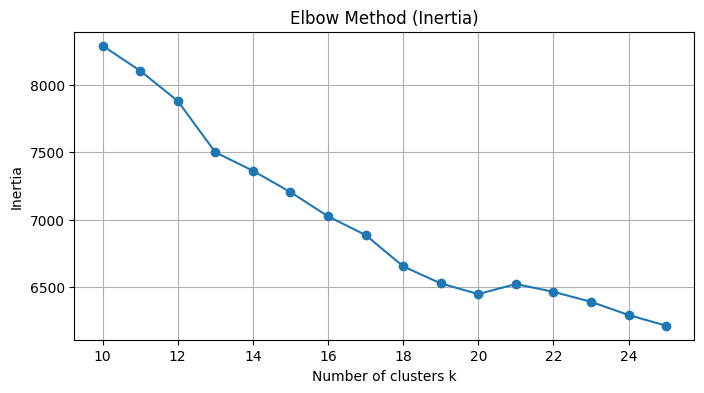

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

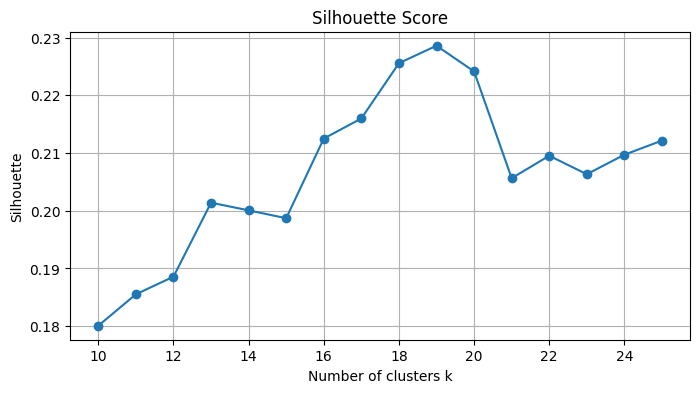

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()


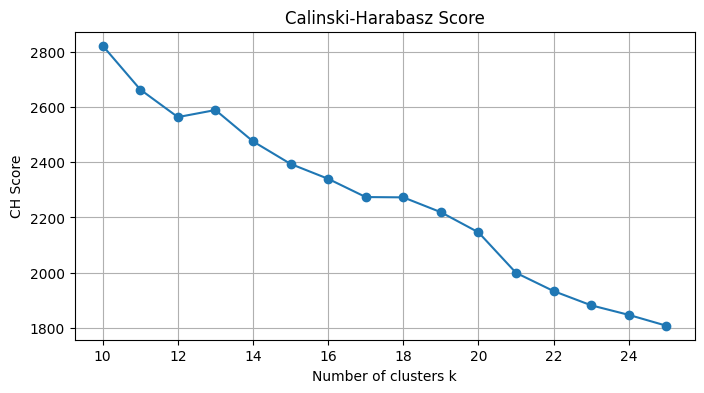

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(k_values, ch_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("Number of clusters k")
plt.ylabel("CH Score")
plt.grid(True)
plt.show()

# Clusterring

In [43]:
n_clusters = 19

In [44]:
X = np.vstack(df['embedding'].values)

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [45]:
display(df[['tags_combined', 'cluster']].head(10))

,tags_combined,cluster
0,security outage disruption data breach,7
1,account disruption outage it tech support,11
2,product feature tech support,16
3,billing payment account documentation feedback,5
4,product feature feedback tech support,16
5,feature product documentation feedback,4
6,outage disruption performance it tech support,11
7,network hardware performance bug compatibility,6
8,documentation feedback it tech support,15
9,disruption outage recovery support,17


In [ ]:
out_path = r"../data/df_with_embedding_and_clusters.csv"
df.to_csv(out_path, index=False)
print("Saved to", out_path)

Saved to C:\Workspace\Python Playground\df_with_embedding_and_clusters.csv


## Name of clusters

In [47]:
df.groupby('cluster')['tags_combined'].apply(lambda x: x.sample(10))

cluster       
0        694               network disruption hardware tech support
         23648              performance network bug it tech support
         23693                  network performance it tech support
         28385    tech support network performance bug outage di...
         15090              network performance bug it tech support
                                        ...                        
18       6596     billing payment investment analytics cost docu...
         5084     it tech support integration data processing au...
         6575        feature data analytics investment optimization
         2411               feature scalability pricing performance
         5159     billing payment subscription investment data a...
Name: tags_combined, Length: 190, dtype: object

In [48]:
def top_words(tags, n=15):
    words = []
    for t in tags:
        t = re.sub(r"[^a-zA-Z ]", " ", t.lower())
        words.extend(t.split())
    return Counter(words).most_common(n)


In [49]:
cluster_groups = (
    df.groupby("cluster")['tags_combined']
    .apply(list)
    .sort_index()
)


In [50]:
cluster_groups

cluster
0     [network disruption vpn tech support, bug cras...
1     [marketing feedback sales lead, product docume...
2     [account security compatibility tech support, ...
3     [video hardware performance compatibility tech...
4     [feature product documentation feedback, refun...
5     [billing payment account documentation feedbac...
6     [network hardware performance bug compatibilit...
7     [security outage disruption data breach, secur...
8     [feature account marketing performance automat...
9     [sales lead feedback marketing customer suppor...
10    [network connectivity performance security har...
11    [account disruption outage it tech support, ou...
12    [it tech support performance feature documenta...
13    [product service feedback sales, product featu...
14    [product documentation security it, compliance...
15    [documentation feedback it tech support, docum...
16    [product feature tech support, product feature...
17    [disruption outage recovery suppor

In [51]:
for cid, tags in cluster_groups.items():
    print("="*80)
    print(f"CLUSTER {cid}")
    print("Tags count:", len(tags))
    print("Top words:", top_words(tags, n=10))
    print("Example tags:", tags[:12])
    print()


CLUSTER 0
Tags count: 2403
Top words: [('network', 2397), ('support', 2394), ('tech', 2326), ('it', 2132), ('performance', 2105), ('bug', 894), ('disruption', 889), ('outage', 480), ('hardware', 277), ('security', 136)]
Example tags: ['network disruption vpn tech support', 'bug crash network performance disruption outage tech support', 'network disruption hardware tech support', 'network performance disruption it tech support', 'network disruption connectivity tech support', 'product hardware network disruption support', 'network performance outage disruption tech support', 'network disruption connectivity tech support', 'disruption service product network cloud it tech support', 'network outage disruption hardware tech support', 'network disruption connectivity tech support', 'network hardware it tech support']

CLUSTER 1
Tags count: 713
Top words: [('feedback', 692), ('sales', 681), ('documentation', 568), ('feature', 336), ('lead', 146), ('marketing', 139), ('product', 103), ('perfo

# Mapping

In [55]:
cluster_mapping = {
    0:  "Network Disruptions & Connectivity Issues",
    1:  "Sales & Marketing Feedback",
    2:  "Security Support Requests",
    3:  "Performance & Bug-Related Tech Issues",
    4:  "Documentation Feedback",
    5:  "Billing & Payment Issues",
    6:  "Software Maintenance & Troubleshooting",
    7:  "Data Privacy & Healthcare Compliance",
    8:  "Marketing Strategy & Campaigns",
    9:  "Sales Support Feedback",
    10: "Security Outages & Incident Response",
    11: "IT Outage Support & Recovery",
    12: "Documentation + Bug Fixing",
    13: "Product Feature Feedback",
    14: "Security Documentation & Compliance",
    15: "Feature Documentation Support",     # ❶ Документация + Feature + Support
    16: "Feature Support Requests",          # ❷ Feature-heavy Support
    17: "Outage Recovery & Maintenance",
    18: "Integration & Analytics",
}

In [56]:
df['cluster_name'] = df['cluster'].map(cluster_mapping)

In [ ]:
out_path = r"../data/df_with_cluster_name.csv"
df.to_csv(out_path, index=False)
print("Saved to", out_path)

Saved to C:\Workspace\Python Playground\df_with_cluster_name.csv


In [72]:
df

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_5,tag_6,tag_7,tag_8,body_length,answer_length,tags_combined,embedding,cluster,cluster_name
0,wesentlicher sicherheitsvorfall,sehr geehrtes support-team n nich möchte einen...,vielen dank für die meldung des kritischen sic...,Incident,Technical Support,high,de,51,security,outage,...,NaN,NaN,NaN,NaN,741,634,security outage disruption data breach,"[-0.010339236, 0.026312996, -0.02845551, 0.048...",7,Data Privacy & Healthcare Compliance
1,account disruption,dear customer support team n ni am writing to ...,thank you for reaching out name we are aware o...,Incident,Technical Support,high,en,51,account,disruption,...,tech support,NaN,NaN,NaN,534,488,account disruption outage it tech support,"[-0.07264027, -0.0054970314, 0.03760734, 0.016...",11,IT Outage Support & Recovery
2,query about smart home system integration feat...,dear customer support team n ni hope this mess...,thank you for your inquiry our products suppor...,Request,Returns and Exchanges,medium,en,51,product,feature,...,NaN,NaN,NaN,NaN,526,494,product feature tech support,"[-0.029368442, 0.0626825, 0.008229229, 0.01602...",16,Feature Support Requests
3,inquiry regarding invoice details,dear customer support team n ni hope this mess...,we appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,billing,payment,...,feedback,NaN,NaN,NaN,593,532,billing payment account documentation feedback,"[-0.07255821, -0.02554824, 0.01098065, 0.02292...",5,Billing & Payment Issues
4,question about marketing agency software compa...,dear support team n ni hope this message reach...,thank you for your inquiry our product support...,Problem,Sales and Pre-Sales,medium,en,51,product,feature,...,NaN,NaN,NaN,NaN,667,268,product feature feedback tech support,"[-0.0356531, 0.03832313, -0.02116072, 0.016278...",16,Feature Support Requests
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28582,performance problem with data analytics tool,the data analytics tool experiences sluggish p...,we are addressing the performance issue with t...,Incident,Technical Support,high,en,400,performance,it,...,NaN,NaN,NaN,NaN,74,266,performance it tech support,"[-0.08990499, 0.047382362, -0.023877406, 0.025...",3,Performance & Bug-Related Tech Issues
28583,datensperrung in der kundschaftsbetreuung,es gab einen datensperrungsunfall bei dem unge...,ich kann ihnen bei dem datensperrungsunfall he...,Incident,Product Support,high,de,400,security,it,...,NaN,NaN,NaN,NaN,406,397,security it tech support bug,"[-0.018605042, 0.021855267, -0.0055052456, 0.0...",2,Security Support Requests
28584,problem mit der videokonferenz-software heute,wichtigere sitzungen wurden unterbrochen durch...,sehr geehrte r name leider wurde das problem m...,Incident,Human Resources,low,de,400,bug,performance,...,tech support,NaN,NaN,NaN,235,579,bug performance network it tech support,"[-0.07437406, 0.008218175, -0.05964678, 0.0147...",0,Network Disruptions & Connectivity Issues
28585,update request for saas platform integration f...,requesting an update on the integration featur...,received your request for updates on the integ...,Change,IT Support,high,en,400,feature,it,...,NaN,NaN,NaN,NaN,281,264,feature it tech support,"[-0.04219642, 0.01103642, -0.01116476, 0.01988...",16,Feature Support Requests


# Data sets separate

In [59]:
df_en = df[df['language'] == 'en'].copy()
df_en.shape

(16338, 22)

In [60]:
df_de = df[df['language'] == 'de'].copy()
df_de.shape

(12249, 22)

# Exploratory Data Analysis (EDA)

## General

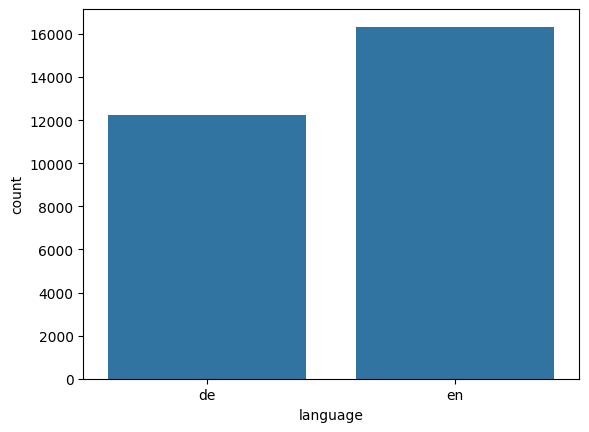

In [61]:
sns.countplot(data = df, x='language') 
plt.show()

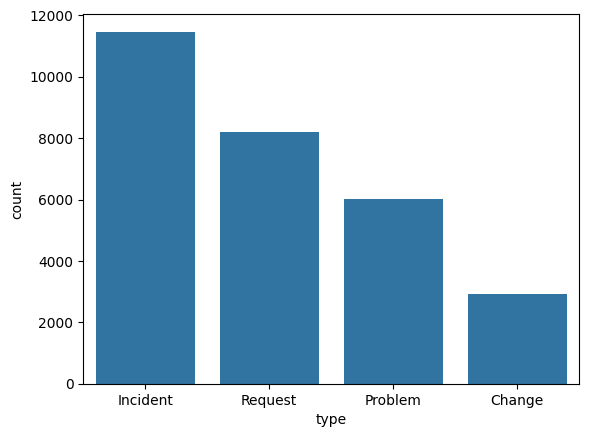

In [62]:
sns.countplot(data = df, x='type')
plt.show()

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_4648\1468480242.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['queue'], order=df['queue'].value_counts().index, palette="coolwarm")


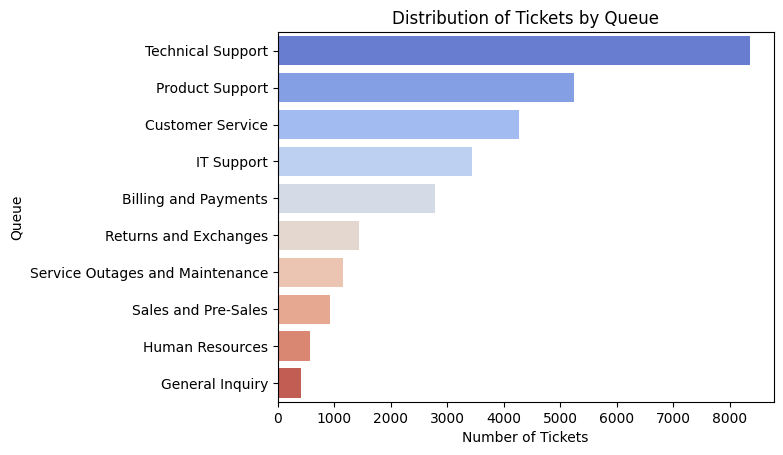

In [63]:
sns.countplot(y=df['queue'], order=df['queue'].value_counts().index, palette="coolwarm")
plt.title("Distribution of Tickets by Queue")
plt.xlabel("Number of Tickets")
plt.ylabel("Queue")
plt.show()

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_4648\3211340575.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['cluster_name'], order=df['cluster_name'].value_counts().index, palette="coolwarm")


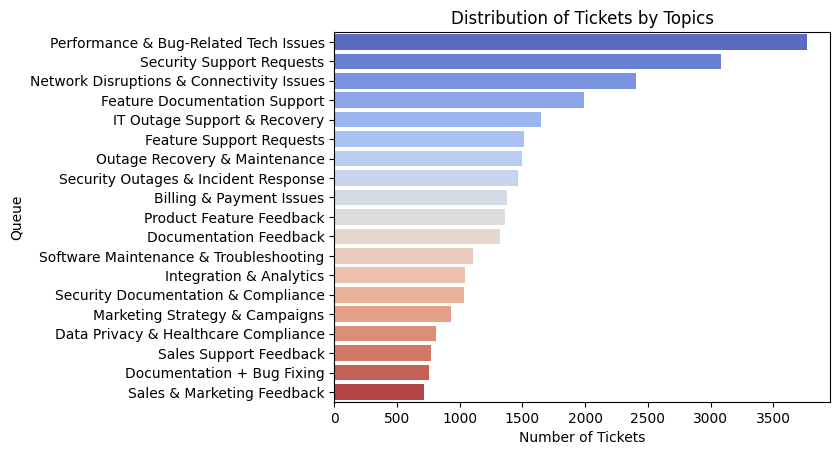

In [64]:
sns.countplot(y=df['cluster_name'], order=df['cluster_name'].value_counts().index, palette="coolwarm")
plt.title("Distribution of Tickets by Topics")
plt.xlabel("Number of Tickets")
plt.ylabel("Queue")
plt.show()

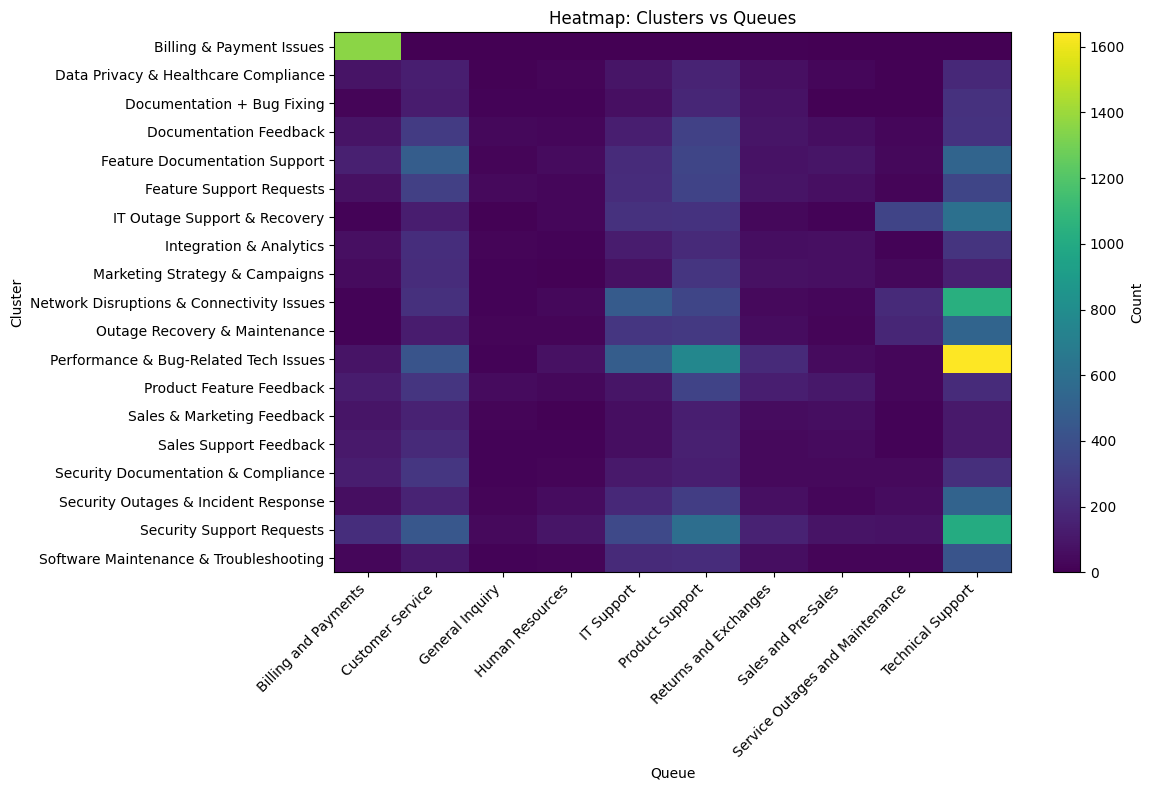

In [70]:
pivot = pd.crosstab(df['cluster_name'], df['queue'])

plt.figure(figsize=(12, 8))
plt.imshow(pivot, aspect='auto')
plt.title("Heatmap: Clusters vs Queues")
plt.xlabel("Queue")
plt.ylabel("Cluster")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label='Count')
plt.tight_layout()
plt.show()

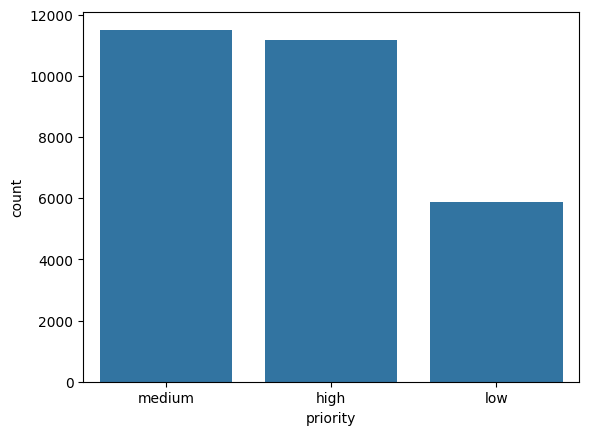

In [65]:
sns.countplot( x=df['priority'],order=df['priority'].value_counts().index)
plt.show()

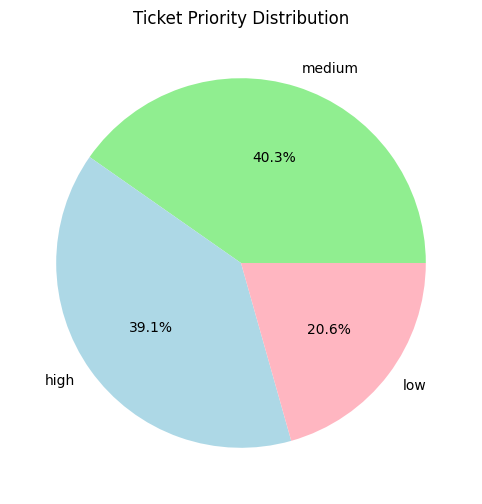

In [67]:
plt.figure(figsize=(8, 6))
df['priority'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'lightblue', 'lightpink'])
plt.title("Ticket Priority Distribution")
plt.ylabel("")
plt.show()

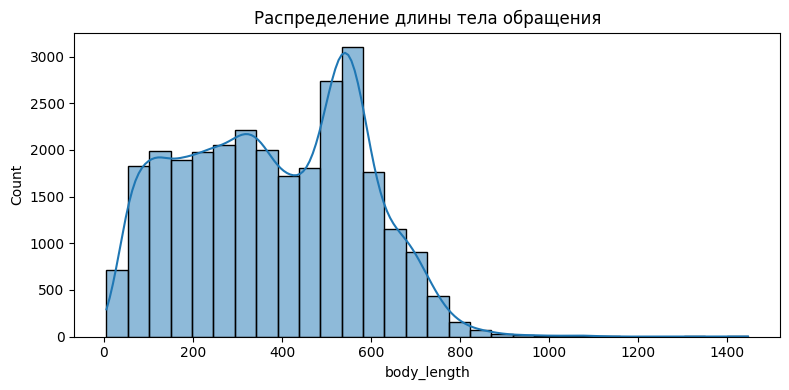

In [68]:
plt.figure(figsize=(8,4))
sns.histplot(df['body_length'], bins=30, kde=True)
plt.title('Распределение длины тела обращения')
plt.xlabel('body_length')
plt.tight_layout()
plt.show()


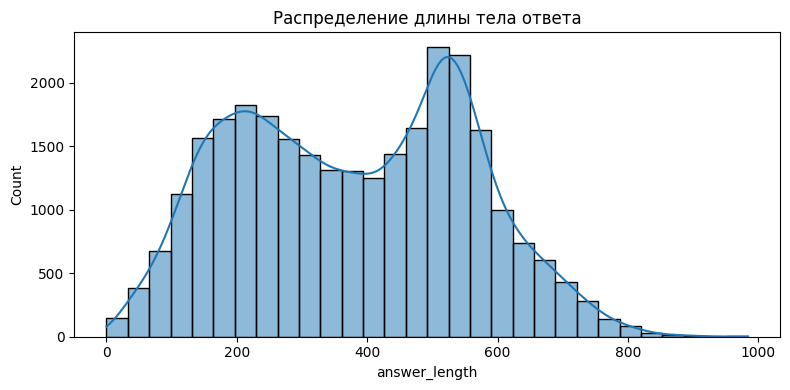

In [69]:
plt.figure(figsize=(8,4))
sns.histplot(df['answer_length'], bins=30, kde=True)
plt.title('Распределение длины тела ответа')
plt.xlabel('answer_length')
plt.tight_layout()
plt.show()


## En

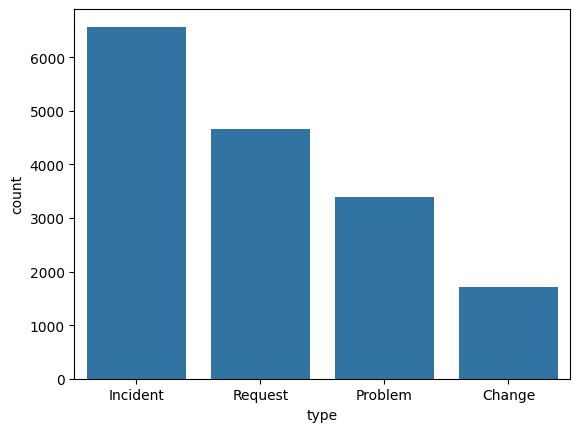

In [50]:
sns.countplot(data = df_en, x='type')
plt.show()

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_5504\2236910113.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_en['queue'], order=df_en['queue'].value_counts().index, palette="coolwarm")


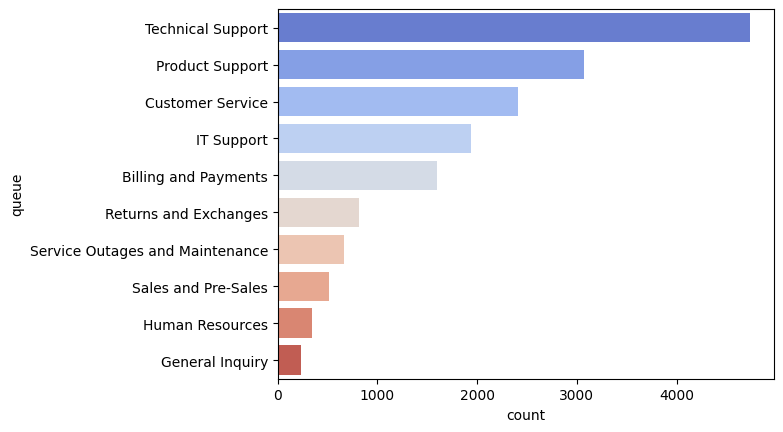

In [51]:
sns.countplot(y=df_en['queue'], order=df_en['queue'].value_counts().index, palette="coolwarm")
plt.show()

## De

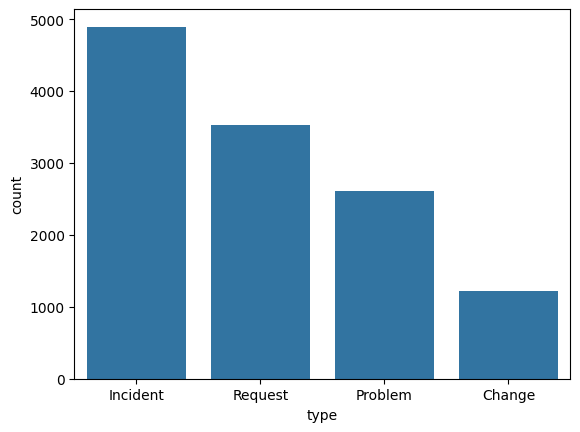

In [52]:
sns.countplot(data = df_de, x='type')
plt.show()

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_5504\2552253092.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_de['queue'], order=df_de['queue'].value_counts().index, palette="coolwarm")


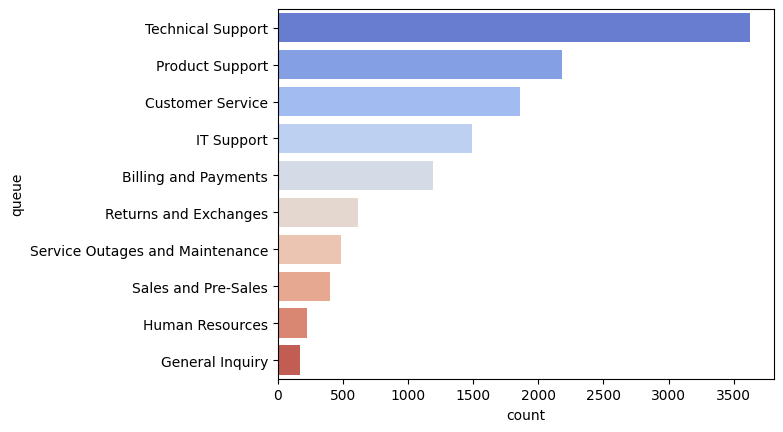

In [53]:
sns.countplot(y=df_de['queue'], order=df_de['queue'].value_counts().index, palette="coolwarm")
plt.show()